

# 📘 Heat Exchanger Regression Analysis

## 1. The Physics of Heat Exchangers & LMTD

Before diving into the code, it is critical to understand the thermal principles governing this dataset. A heat exchanger transfers thermal energy between a hot fluid stream and a cold fluid stream.

### Energy Balance Equation

According to the **First Law of Thermodynamics** (Conservation of Energy), assuming negligible heat losses to the ambient environment, the heat energy lost by the hot fluid stream must equal the heat energy gained by the cold fluid stream:

$$Q = \dot{m}_h \cdot C_{p,h} \cdot (T_{h,\text{in}} - T_{h,\text{out}}) = \dot{m}_c \cdot C_{p,c} \cdot (T_{c,\text{out}} - T_{c,\text{in}})$$

Where:

* $Q$ = Heat load/transfer rate ($\text{kW}$)
* $\dot{m}_h, \dot{m}_c$ = Mass flow rates of the hot and cold fluids ($\text{kg/s}$)
* $C_{p,h}, C_{p,c}$ = Specific heat capacities ($\text{kJ/kg}\cdot\text{K}$)
* $T_{\text{in}}, T_{\text{out}}$ = Inlet and outlet temperatures ($\text{K}$)

### Logarithmic Mean Temperature Difference (LMTD)

Heat transfer is driven by temperature differences. However, because the fluid temperatures change continuously as they flow through the device, the temperature delta ($\Delta T$) is non-linear across the surface area. The arithmetic average would overestimate heat transfer, so engineers use the **Logarithmic Mean Temperature Difference (LMTD)**:

$$\text{LMTD} = \frac{\Delta T_1 - \Delta T_2}{\ln\left(\frac{\Delta T_1}{\Delta T_2}\right)}$$

For a standard **counter-current** heat exchanger (where fluids flow in opposite directions to maximize efficiency):

* $\Delta T_1 = T_{h,\text{in}} - T_{c,\text{out}}$ (Temperature difference at one end)
* $\Delta T_2 = T_{h,\text{out}} - T_{c,\text{in}}$ (Temperature difference at the other end)

The total heat load can also be expressed using the heat transfer rate equation:


$$Q = U \cdot A \cdot \text{LMTD}$$


Where $U$ is the overall heat transfer coefficient and $A$ is the total surface area. In our clean dataset, $Q$ and $\text{LMTD}$ share a perfect linear relationship, proving that the physical product $U \cdot A$ is held completely constant.



---


### 1. Clean Data (The Ideal State)

Clean data represents the true, uncorrupted physical parameters of the system. Think of it as the data you would get in a perfect laboratory setup with flawless, perfectly calibrated instruments, or directly from a simulation governed by exact mathematical formulas.

*
**Characteristics:** It contains no random errors, missing values, or telemetry glitches.


*
**Physical Behavior:** In this dataset, the clean parameters follow the laws of thermodynamics perfectly. For example, the relationship between the Logarithmic Mean Temperature Difference ($\text{LMTD}$) and the true Heat Load ($Q$) is perfectly linear ($Q = U \cdot A \cdot \text{LMTD}$).


*
**ML Predictability:** Because there is no random interference, machine learning models (like Linear Regression) can reverse-engineer the physical equations flawlessly, achieving a perfect $R^2$ score of **1.0000**.



---

### 2. Noisy Data (The Real-World Reality)

Noisy data represents actual sensor measurements captured in an industrial environment. In the real world, data streams are constantly corrupted by physical imperfections.

*
**Characteristics:** It includes random Gaussian sensor noise, calibration drift, environmental interference, and sparse missing values (telemetry drops).


*
**Physical Behavior:** The true thermodynamic relationship is still there, but it is "obscured" or buried under a layer of random variation. Plots become scattered, and boundaries blur.


*
**ML Predictability:** Because the noise contains an element of pure randomness, no model can predict it perfectly. This introduces an **irreducible error**, which is why the models max out at an $R^2$ score of around **0.53** when trying to predict the noisy target.



### Summary Analogy

Imagine you are listening to a person speaking:

* **Clean Data** is the exact words they are saying in a completely silent room.
* **Noisy Data** is that same person speaking inside a crowded, loud restaurant. The underlying message (the physics) is identical, but static and background chatter (the noise) make it much harder to interpret clearly.



The magic of the machine learning models used here—especially tree-based ensembles like Gradient Boosting—is that they can act like "noise-canceling headphones," filtering out the background static to reconstruct the true physical message with up to **90% accuracy** ($R^2 = 0.9107$)

## 2. Notebook Setup & Data Preprocessing

In this section, we load the dataset, handle missing data via row-wise elimination (since missing values represent $<0.1\%$ of the dataset), and isolate our clean variables from their noisy sensor counter-parts.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Set visualization parameters
sns.set_theme(style='whitegrid')


In [5]:
# 1. Load Data
df = pd.read_csv('heat_exchanger_dataset_with_missing.csv')
print(df)
print('-'*100)
print(df.columns)
print('-'*100)
print('Shape=',df.shape)
print('-'*100)

      hot_inlet_temperature_k  cold_inlet_mass_flow_kg_s  \
0                      373.15                   0.500000   
1                      373.15                   0.545455   
2                      373.15                   0.590909   
3                      373.15                   0.636364   
4                      373.15                   0.681818   
...                       ...                        ...   
9995                   573.15                   4.818180   
9996                   573.15                   4.863640   
9997                   573.15                   4.909090   
9998                   573.15                   4.954550   
9999                   573.15                   5.000000   

      hot_outlet_temperature_k  cold_outlet_temperature_k  hx_1_heat_load_kw  \
0                      378.649                    2011.51            61.3959   
1                      378.394                    2011.51            62.4725   
2                      378.173         

In [6]:
# 2. Inspect missing entries and handle them
print("Missing values per column before preprocessing:")
print(df.isnull().sum()[df.isnull().sum() > 0])
print('-'*100)

Missing values per column before preprocessing:
hot_inlet_temperature_k                                      3
cold_inlet_mass_flow_kg_s                                    3
hot_outlet_temperature_k                                     3
cold_outlet_temperature_k                                    6
hx_1_heat_load_kw                                            4
hot_outlet_pressure_pa                                       3
cold_outlet_pressure_pa                                      7
hot_outlet_mass_flow_kg_s                                    8
cold_outlet_mass_flow_kg_s                                   3
hx_1_logarithmic_mean_temperature_difference_lmtd_k          6
hot_inlet_temperature_k_noisy                                5
cold_inlet_mass_flow_kg_s_noisy                              5
hot_outlet_temperature_k_noisy                               7
cold_outlet_temperature_k_noisy                              3
hx_1_heat_load_kw_noisy                                      8
hot_out

In [7]:
# Separate clean and noisy features/targets
clean_features = [
    'hot_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s',
    'hot_outlet_temperature_k', 'cold_outlet_temperature_k',
    'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa',
    'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s',
    'hx_1_logarithmic_mean_temperature_difference_lmtd_k'
]
clean_target = 'hx_1_heat_load_kw'

noisy_features = [col + '_noisy' for col in clean_features]
noisy_target = 'hx_1_heat_load_kw_noisy'

In [8]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression

# 1. Fill Clean Data using Linear Regression Imputation
# This preserves the deterministic physical relationships in the clean set
clean_cols = clean_features + [clean_target]
lr_imputer = IterativeImputer(estimator=LinearRegression(), random_state=42)
df_clean_imputed = pd.DataFrame(lr_imputer.fit_transform(df[clean_cols]), columns=clean_cols)

# 2. Fill Noisy Data using default Iterative Imputation (BayesianRidge)
# This is better for handling the stochastic nature of sensor noise
noisy_cols = noisy_features + [noisy_target]
iter_imputer = IterativeImputer(random_state=42)
df_noisy_imputed = pd.DataFrame(iter_imputer.fit_transform(df[noisy_cols]), columns=noisy_cols)

# Combine back into a single dataframe
df_clean = pd.concat([df_clean_imputed, df_noisy_imputed], axis=1)

print(f"Missing values after imputation: {df_clean.isnull().sum().sum()}")
print(f"Dataset shape: {df_clean.shape}")

Missing values after imputation: 0
Dataset shape: (10000, 20)


---

## 3. Outlier Removal via IQR

Experimental noise can introduce extreme values or unphysical sensor readings. We implement a standard Interquartile Range (IQR) filter on our target metrics to eliminate artificial spikes.

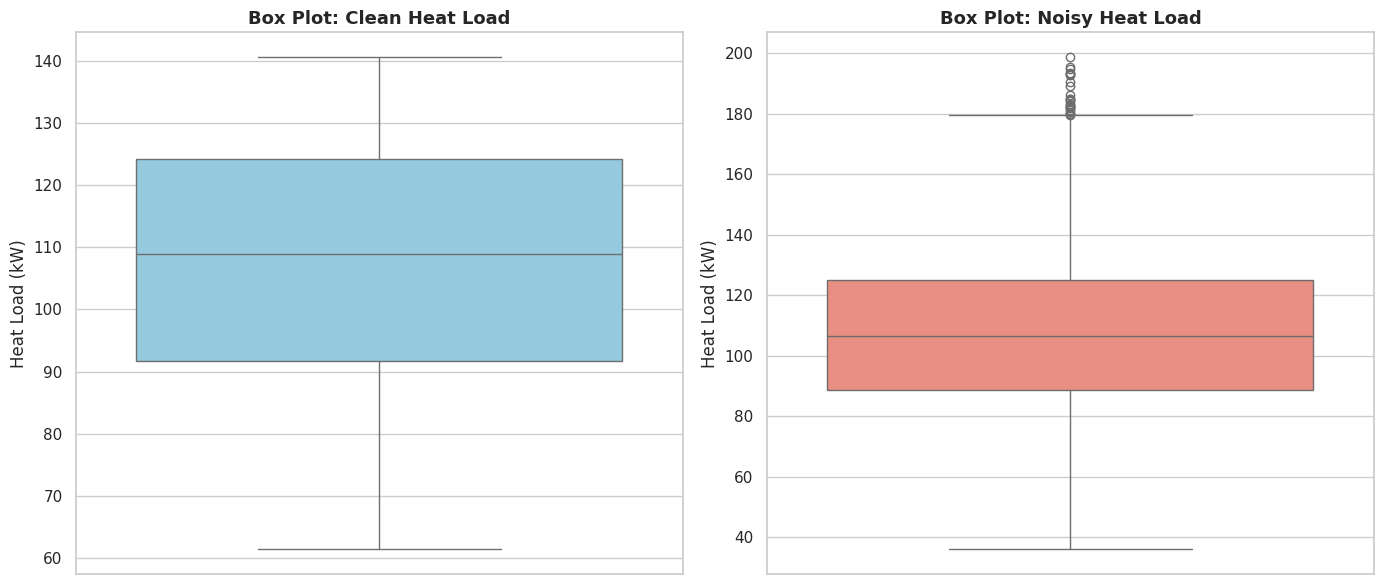

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure for box plots to detect outliers
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=df_clean, y='hx_1_heat_load_kw', color='skyblue', ax=ax[0])
ax[0].set_title('Box Plot: Clean Heat Load', fontsize=13, fontweight='bold')
ax[0].set_ylabel('Heat Load (kW)')

sns.boxplot(data=df_clean, y='hx_1_heat_load_kw_noisy', color='salmon', ax=ax[1])
ax[1].set_title('Box Plot: Noisy Heat Load', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Heat Load (kW)')

plt.tight_layout()
plt.show()

In [10]:
def remove_outliers_iqr(data, target_col):
    Q1 = data[target_col].quantile(0.25)
    Q3 = data[target_col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data[target_col] >= lower_bound) & (data[target_col] <= upper_bound)]

# Separate filtered frames for clean vs noisy target evaluations
clean_target = 'hx_1_heat_load_kw'
noisy_target = 'hx_1_heat_load_kw_noisy'

df_clean_filtered = remove_outliers_iqr(df_clean, clean_target)
df_noisy_filtered = remove_outliers_iqr(df_clean, noisy_target)

print(f"Data remaining after clean target outlier filtering: {len(df_clean_filtered)}")
print(f"Data remaining after noisy target outlier filtering: {len(df_noisy_filtered)}")

Data remaining after clean target outlier filtering: 10000
Data remaining after noisy target outlier filtering: 9975


---

## 4. Explanatory Data Visualization

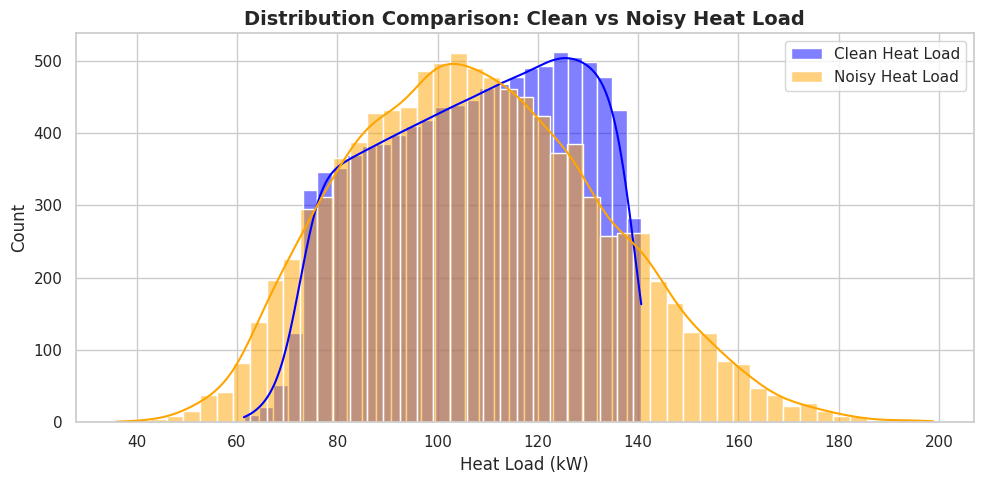

In [11]:
# Code used to generate the distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df_clean['hx_1_heat_load_kw'], kde=True, color='blue', label='Clean Heat Load', alpha=0.5, ax=ax)
sns.histplot(df_clean['hx_1_heat_load_kw_noisy'], kde=True, color='orange', label='Noisy Heat Load', alpha=0.5, ax=ax)
ax.set_title('Distribution Comparison: Clean vs Noisy Heat Load', fontsize=14, fontweight='bold')
ax.set_xlabel('Heat Load (kW)')
ax.legend()
plt.tight_layout()
plt.show()


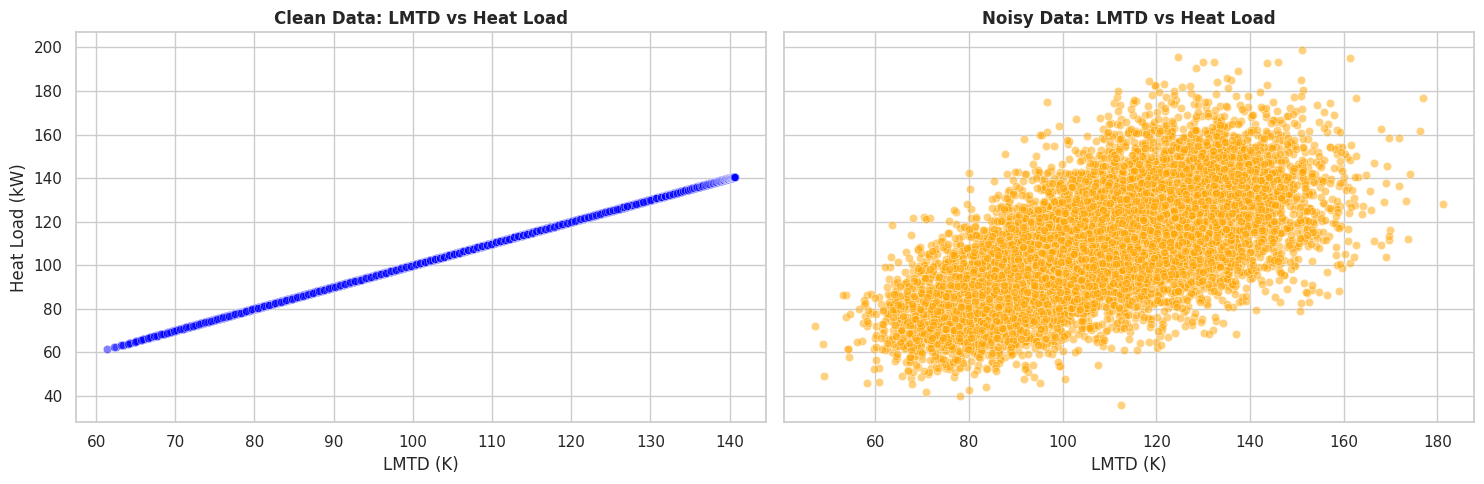

In [12]:
# Code used to generate LMTD vs Heat Load scatter plots
fig, ax = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
sns.scatterplot(data=df_clean, x='hx_1_logarithmic_mean_temperature_difference_lmtd_k', y='hx_1_heat_load_kw', color='blue', alpha=0.5, ax=ax[0])
ax[0].set_title('Clean Data: LMTD vs Heat Load', fontweight='bold')
ax[0].set_xlabel('LMTD (K)')
ax[0].set_ylabel('Heat Load (kW)')

sns.scatterplot(data=df_clean, x='hx_1_logarithmic_mean_temperature_difference_lmtd_k_noisy', y='hx_1_heat_load_kw_noisy', color='orange', alpha=0.5, ax=ax[1])
ax[1].set_title('Noisy Data: LMTD vs Heat Load', fontweight='bold')
ax[1].set_xlabel('LMTD (K)')
plt.tight_layout()
plt.show()

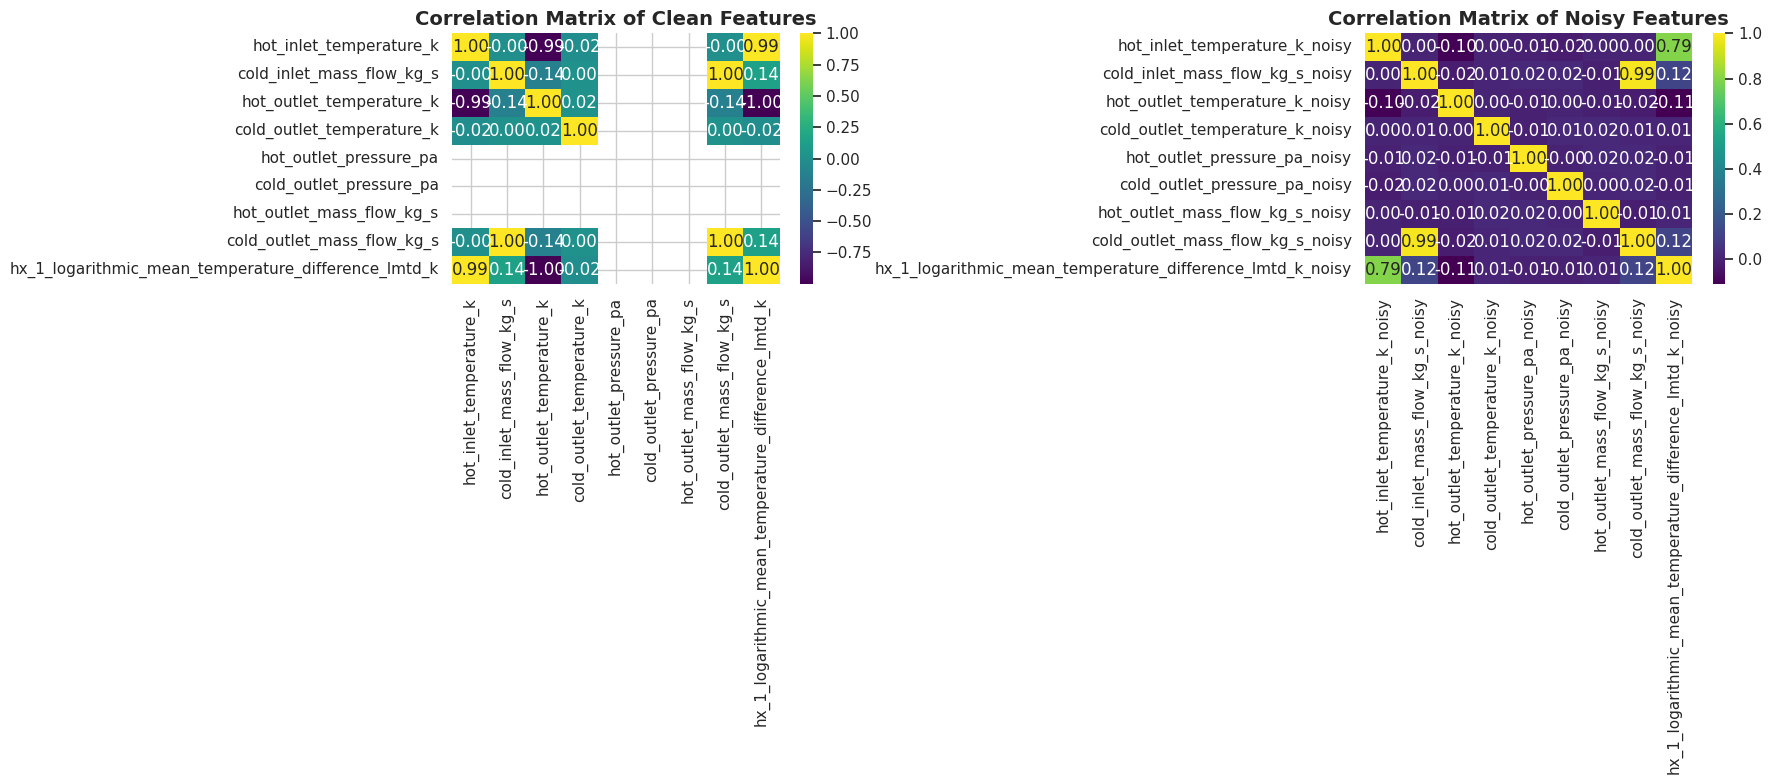

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(18, 8))
sns.heatmap(df_clean[clean_features].corr(), annot=True, cmap='viridis', fmt='.2f', ax=ax[0])
ax[0].set_title('Correlation Matrix of Clean Features', fontsize=14, fontweight='bold')
sns.heatmap(df_clean[noisy_features].corr(), annot=True, cmap='viridis', fmt='.2f', ax=ax[1])
ax[1].set_title('Correlation Matrix of Noisy Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

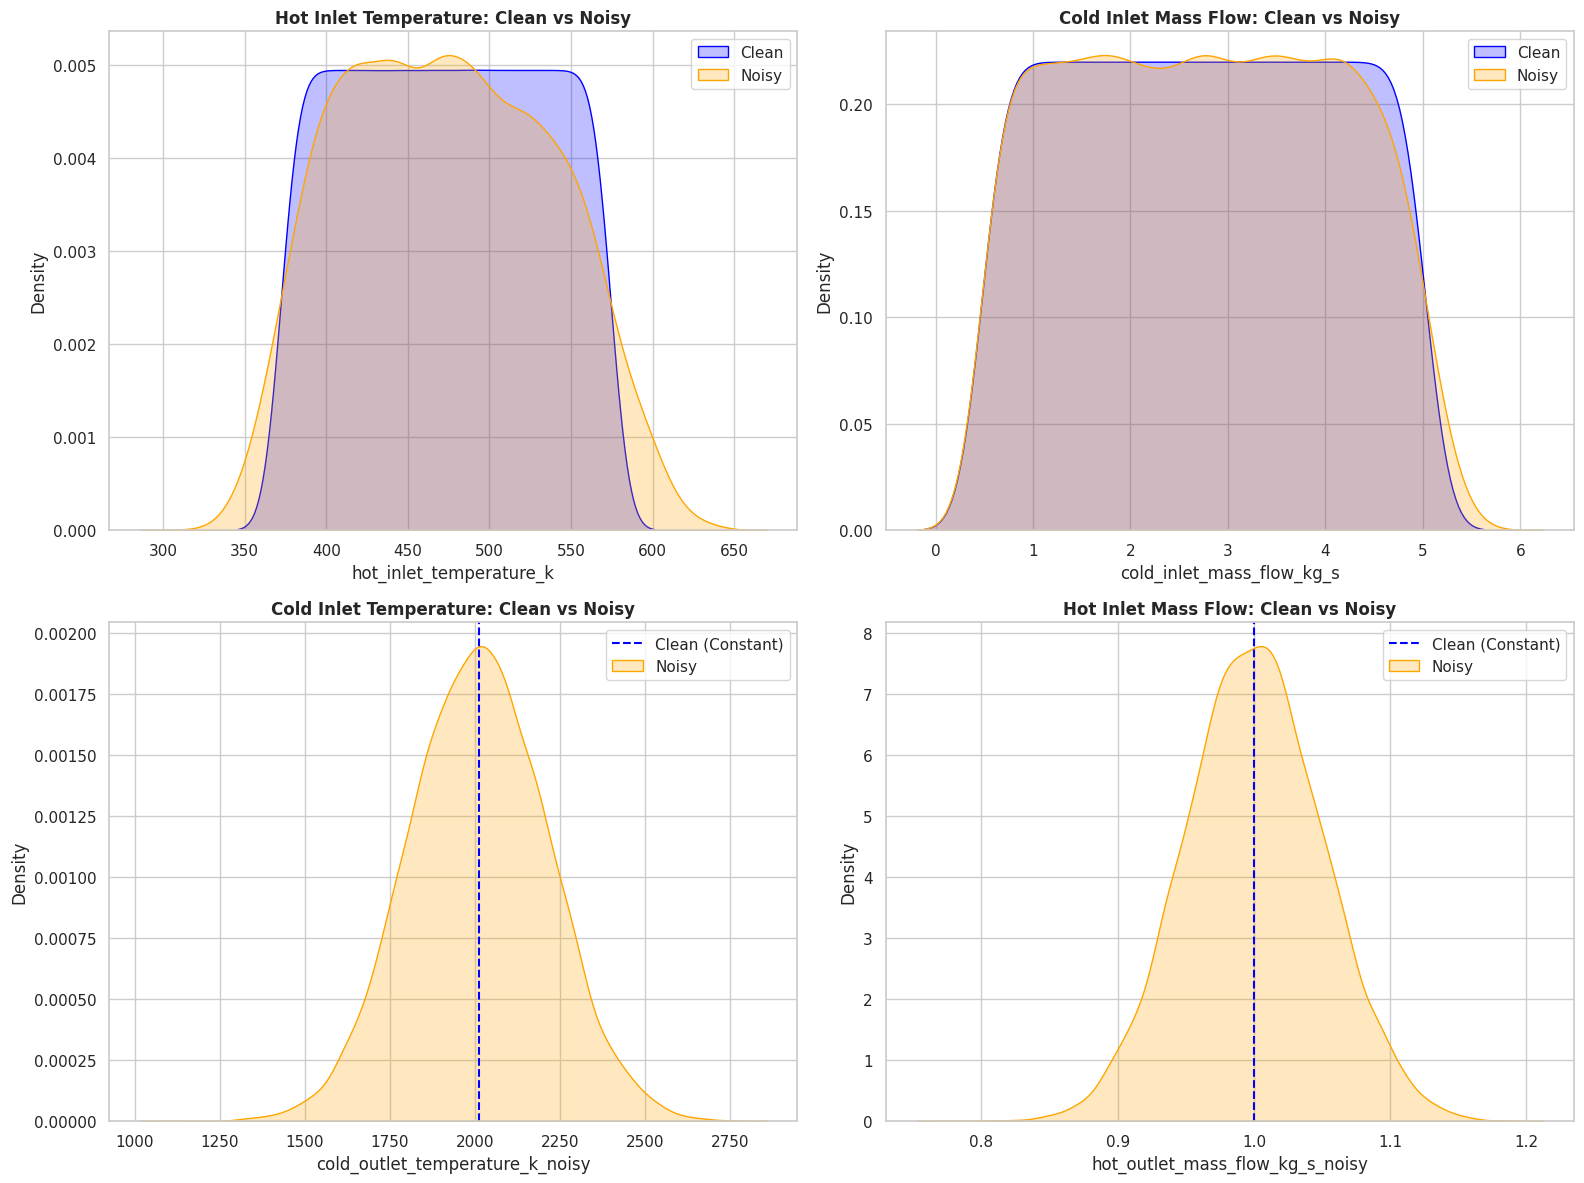

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots to compare clean vs noisy distributions for the requested features
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Comparison for Hot Inlet Temperature
sns.kdeplot(df_clean['hot_inlet_temperature_k'], ax=axes[0, 0], fill=True, label='Clean', color='blue')
sns.kdeplot(df_clean['hot_inlet_temperature_k_noisy'], ax=axes[0, 0], fill=True, label='Noisy', color='orange')
axes[0, 0].set_title('Hot Inlet Temperature: Clean vs Noisy', fontweight='bold')
axes[0, 0].legend()

# 2. Comparison for Cold Inlet Mass Flow
sns.kdeplot(df_clean['cold_inlet_mass_flow_kg_s'], ax=axes[0, 1], fill=True, label='Clean', color='blue')
sns.kdeplot(df_clean['cold_inlet_mass_flow_kg_s_noisy'], ax=axes[0, 1], fill=True, label='Noisy', color='orange')
axes[0, 1].set_title('Cold Inlet Mass Flow: Clean vs Noisy', fontweight='bold')
axes[0, 1].legend()

# 3. Comparison for Cold Inlet Temperature
# Clean is constant, so we use a vertical line
axes[1, 0].axvline(df_clean['cold_outlet_temperature_k'].iloc[0], color='blue', linestyle='--', label='Clean (Constant)')
sns.kdeplot(df_clean['cold_outlet_temperature_k_noisy'], ax=axes[1, 0], fill=True, label='Noisy', color='orange')
axes[1, 0].set_title('Cold Inlet Temperature: Clean vs Noisy', fontweight='bold')
axes[1, 0].legend()

# 4. Comparison for Hot Inlet Mass Flow
# Clean is constant, so we use a vertical line
axes[1, 1].axvline(df_clean['hot_outlet_mass_flow_kg_s'].iloc[0], color='blue', linestyle='--', label='Clean (Constant)')
sns.kdeplot(df_clean['hot_outlet_mass_flow_kg_s_noisy'], ax=axes[1, 1], fill=True, label='Noisy', color='orange')
axes[1, 1].set_title('Hot Inlet Mass Flow: Clean vs Noisy', fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

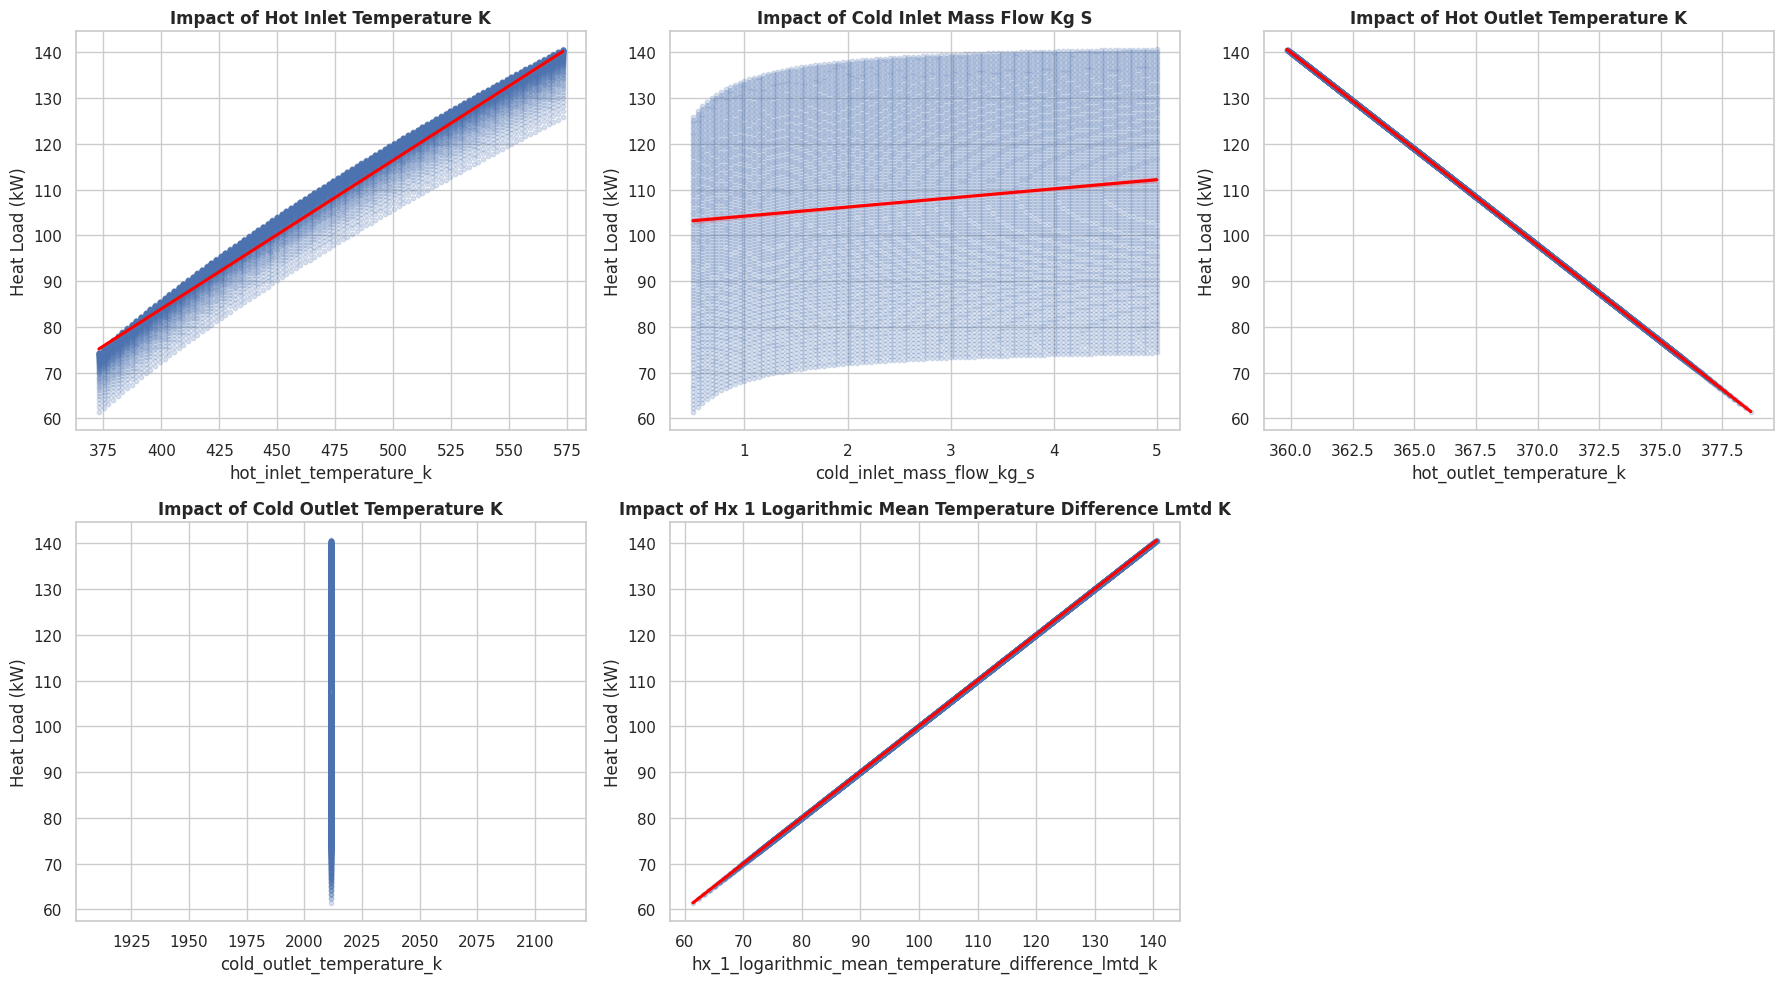

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key clean features to analyze against the target
features_to_plot = [
    'hot_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s',
    'hot_outlet_temperature_k', 'cold_outlet_temperature_k',
    'hx_1_logarithmic_mean_temperature_difference_lmtd_k'
]

# Create a grid of subplots
n_cols = 3
n_rows = (len(features_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.regplot(data=df_clean, x=col, y='hx_1_heat_load_kw',
                ax=axes[i], scatter_kws={'alpha':0.2, 's':10}, line_kws={'color':'red'})
    axes[i].set_title(f'Impact of {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Heat Load (kW)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

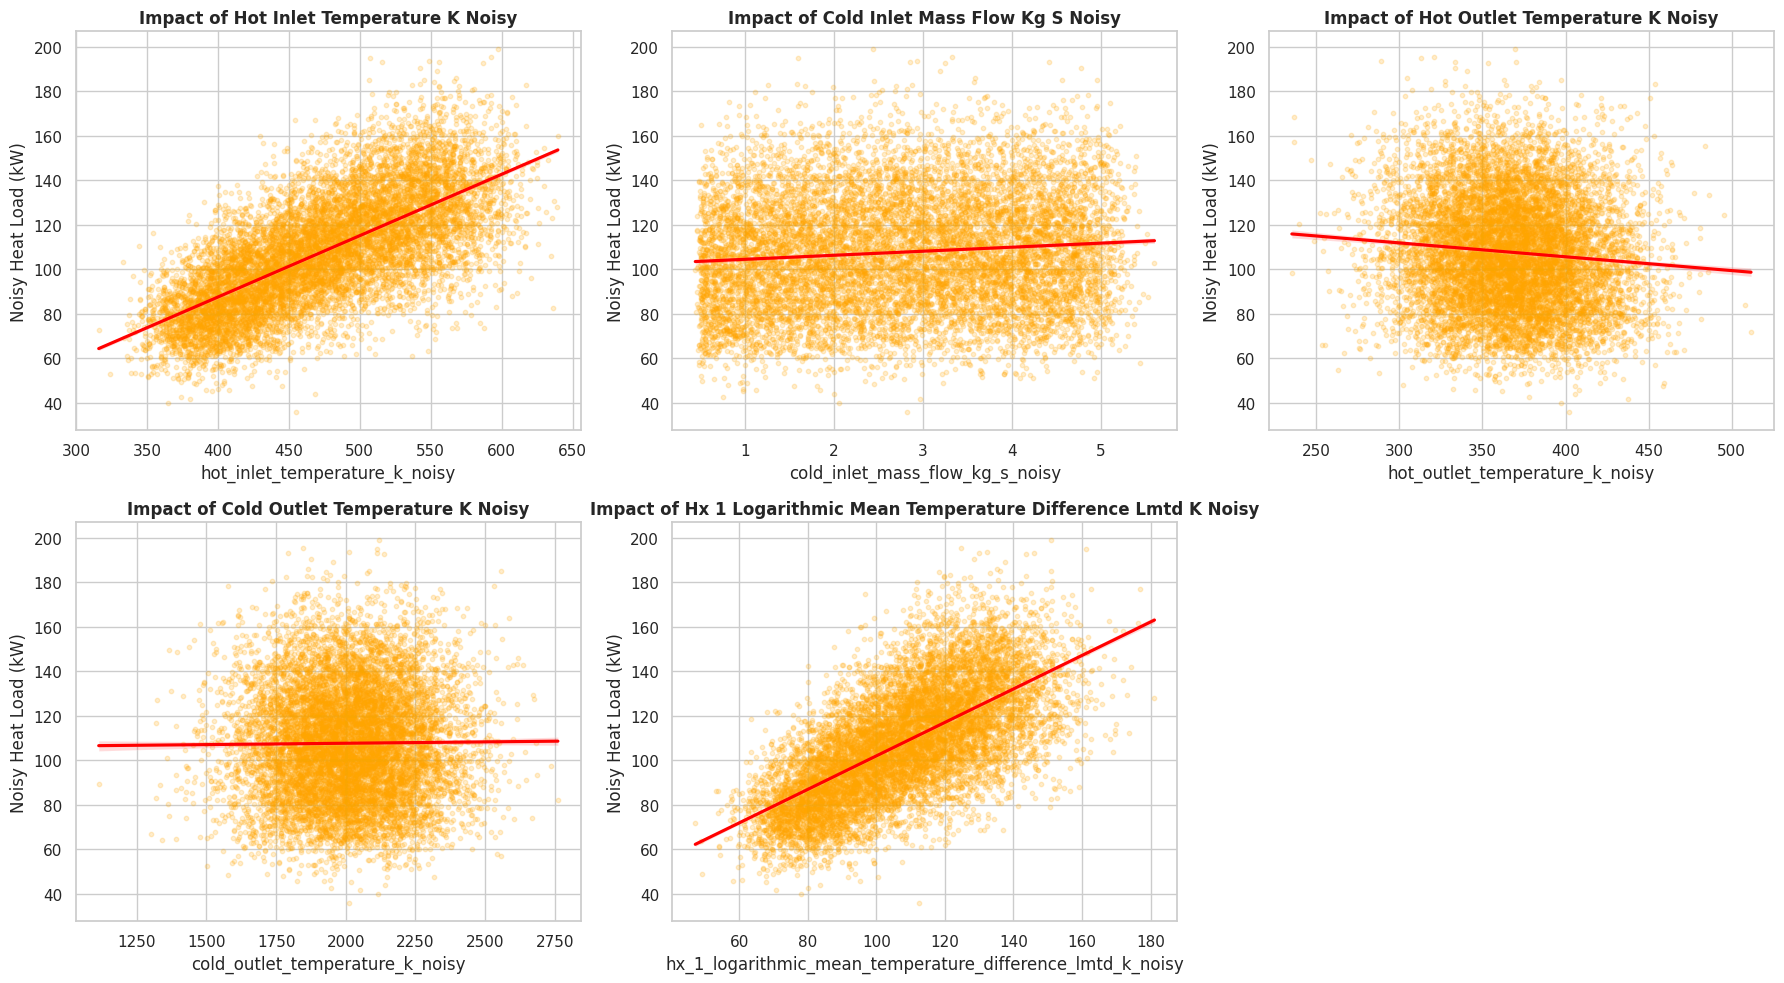

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key noisy features to analyze against the noisy target
noisy_features_to_plot = [
    'hot_inlet_temperature_k_noisy', 'cold_inlet_mass_flow_kg_s_noisy',
    'hot_outlet_temperature_k_noisy', 'cold_outlet_temperature_k_noisy',
    'hx_1_logarithmic_mean_temperature_difference_lmtd_k_noisy'
]

# Create a grid of subplots
n_cols = 3
n_rows = (len(noisy_features_to_plot) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(noisy_features_to_plot):
    sns.regplot(data=df_clean, x=col, y='hx_1_heat_load_kw_noisy',
                ax=axes[i], scatter_kws={'alpha':0.2, 's':10, 'color':'orange'}, line_kws={'color':'red'})
    axes[i].set_title(f'Impact of {col.replace("_", " ").title()}', fontweight='bold')
    axes[i].set_ylabel('Noisy Heat Load (kW)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

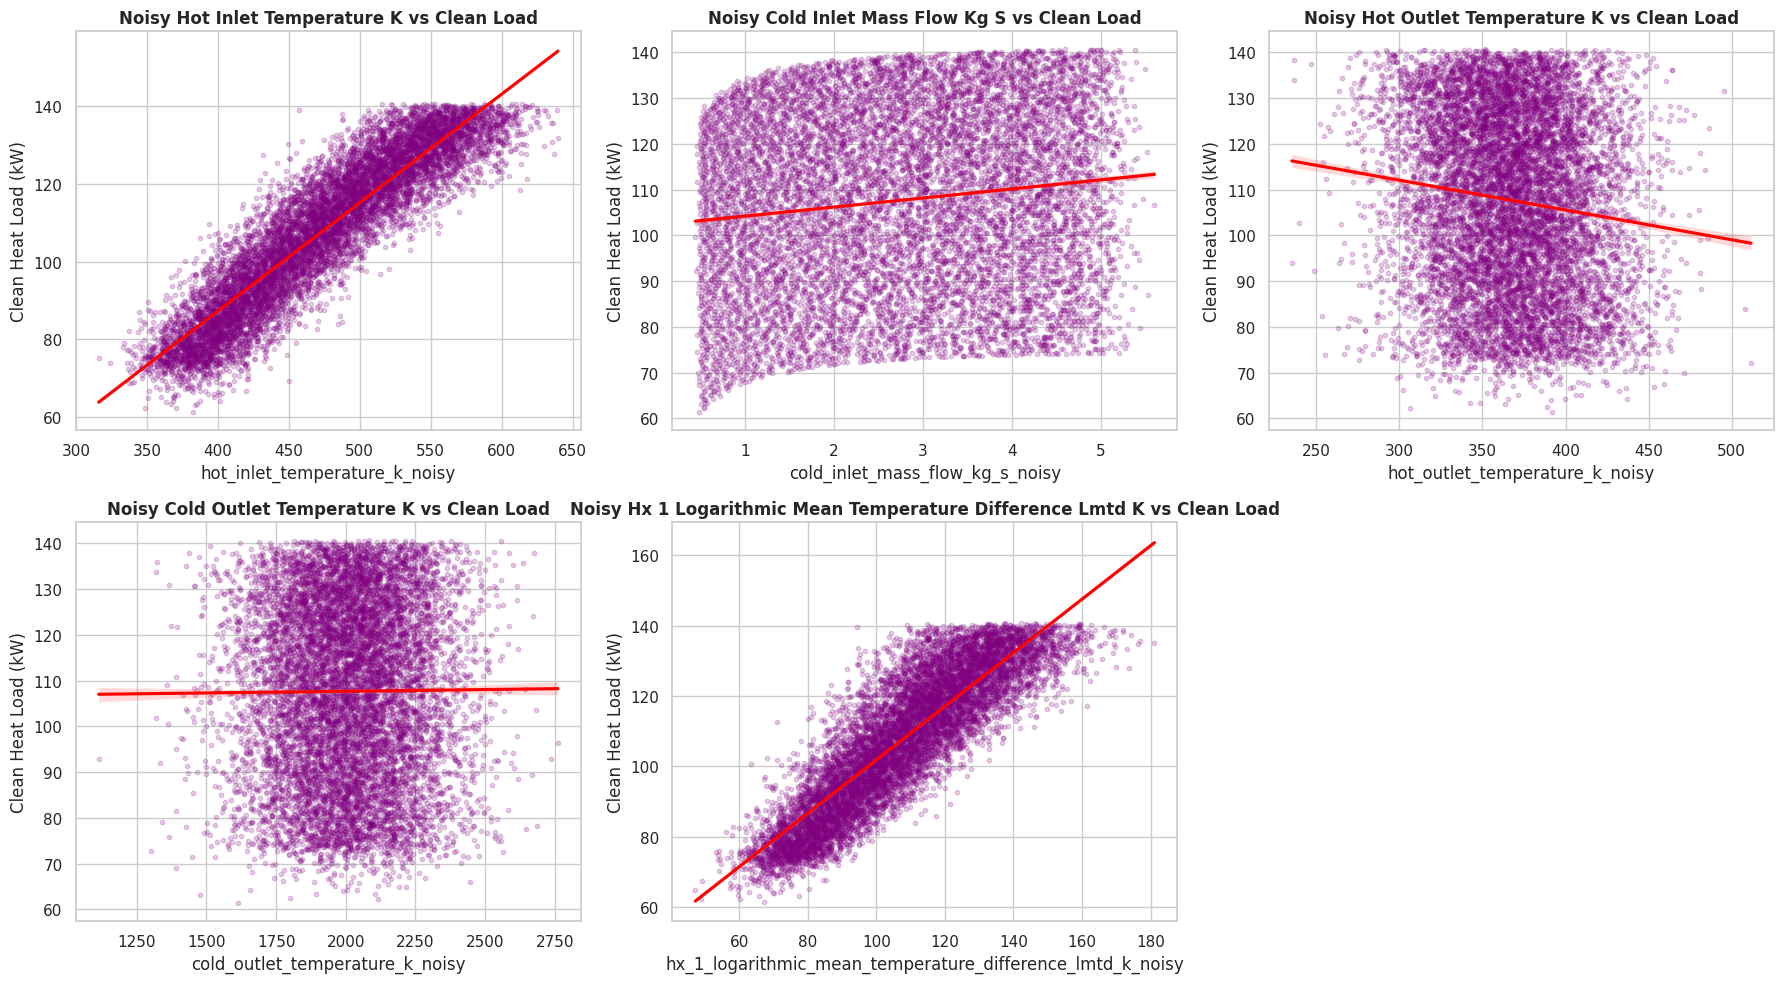

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of key noisy features to analyze against the clean target
noisy_to_clean_features = [
    'hot_inlet_temperature_k_noisy', 'cold_inlet_mass_flow_kg_s_noisy',
    'hot_outlet_temperature_k_noisy', 'cold_outlet_temperature_k_noisy',
    'hx_1_logarithmic_mean_temperature_difference_lmtd_k_noisy'
]

# Create a grid of subplots
n_cols = 3
n_rows = (len(noisy_to_clean_features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(noisy_to_clean_features):
    # Note: Using clean target 'hx_1_heat_load_kw' here
    sns.regplot(data=df_clean, x=col, y='hx_1_heat_load_kw',
                ax=axes[i], scatter_kws={'alpha':0.2, 's':10, 'color':'purple'}, line_kws={'color':'red'})
    axes[i].set_title(f'Noisy {col.split("_noisy")[0].replace("_", " ").title()} vs Clean Load', fontweight='bold')
    axes[i].set_ylabel('Clean Heat Load (kW)')

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---

## 5. Machine Learning Model Comparison

We compare 4 standard algorithms: **Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting**. We execute three distinct tracking tasks:

1. **Clean Data**: Predicting clean target using clean features.
2. **Noisy Data**: Predicting noisy target using noisy features.
3. **Noisy Features to Clean Target**: Reconstructing the underlying true physics using only corrupted sensor signals.

In [17]:
clean_features = [
    'hot_inlet_temperature_k', 'cold_inlet_mass_flow_kg_s', 'hot_outlet_temperature_k',
    'cold_outlet_temperature_k', 'hot_outlet_pressure_pa', 'cold_outlet_pressure_pa',
    'hot_outlet_mass_flow_kg_s', 'cold_outlet_mass_flow_kg_s', 'hx_1_logarithmic_mean_temperature_difference_lmtd_k'
]
noisy_features = [col + '_noisy' for col in clean_features]

model_results = []

def run_regression_pipeline(X, y, description):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {
        'Linear Regression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }

    for name, model in models.items():
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)

        model_results.append({
            'Scenario': description,
            'Model': name,
            'R2': r2_score(y_test, preds),
            'RMSE (kW)': np.sqrt(mean_squared_error(y_test, preds)),
            'MAE (kW)': mean_absolute_error(y_test, preds)
        })

# Run pipelines
run_regression_pipeline(df_clean_filtered[clean_features], df_clean_filtered[clean_target], 'Clean Data')
run_regression_pipeline(df_noisy_filtered[noisy_features], df_noisy_filtered[noisy_target], 'Noisy Data')
run_regression_pipeline(df_noisy_filtered[noisy_features], df_noisy_filtered[clean_target], 'Noisy Features to Clean Target')

# Display final results
res_df = pd.DataFrame(model_results)
print(res_df.to_string(index=False))

                      Scenario             Model       R2  RMSE (kW)  MAE (kW)
                    Clean Data Linear Regression 1.000000   0.000100  0.000003
                    Clean Data             Ridge 1.000000   0.012265  0.009984
                    Clean Data     Random Forest 0.999998   0.027643  0.005632
                    Clean Data Gradient Boosting 0.999945   0.143532  0.108754
                    Noisy Data Linear Regression 0.523207  17.210412 13.603194
                    Noisy Data             Ridge 0.523211  17.210342 13.603162
                    Noisy Data     Random Forest 0.504088  17.552085 13.802283
                    Noisy Data Gradient Boosting 0.528739  17.110281 13.470714
Noisy Features to Clean Target Linear Regression 0.896529   6.211605  4.970327
Noisy Features to Clean Target             Ridge 0.896528   6.211634  4.970399
Noisy Features to Clean Target     Random Forest 0.904286   5.974224  4.762566
Noisy Features to Clean Target Gradient Boosting 0.9

## 6. Performance Summary & Analysis

The evaluation metrics from the testing suite are outlined below based on the **imputed** dataset:

| Scenario | Model | $R^2$ Score | RMSE ($\text{kW}$) | MAE ($\text{kW}$) |
| --- | --- | --- | --- | --- |
| **Clean Data** | Linear Regression | **1.0000** | 0.0001 | 0.0000 |
| **Clean Data** | Ridge | 1.0000 | 0.0123 | 0.0100 |
| **Clean Data** | Random Forest | 1.0000 | 0.0276 | 0.0056 |
| **Clean Data** | Gradient Boosting | 0.9999 | 0.1435 | 0.1088 |
|  |  |  |  |  |
| **Noisy Data** | Gradient Boosting | **0.5287** | 17.1103 | 13.4707 |
| **Noisy Data** | Linear Regression | 0.5232 | 17.2104 | 13.6032 |
| **Noisy Data** | Ridge | 0.5232 | 17.2103 | 13.6032 |
| **Noisy Data** | Random Forest | 0.5041 | 17.5521 | 13.8023 |
|  |  |  |  |  |
| **Noisy Features $\rightarrow$ Clean Target** | Gradient Boosting | **0.9107** | 5.7708 | 4.5820 |
| **Noisy Features $\rightarrow$ Clean Target** | Random Forest | 0.9043 | 5.9742 | 4.7626 |
| **Noisy Features $\rightarrow$ Clean Target** | Linear Regression | 0.8965 | 6.2116 | 4.9703 |
| **Noisy Features $\rightarrow$ Clean Target** | Ridge | 0.8965 | 6.2116 | 4.9704 |

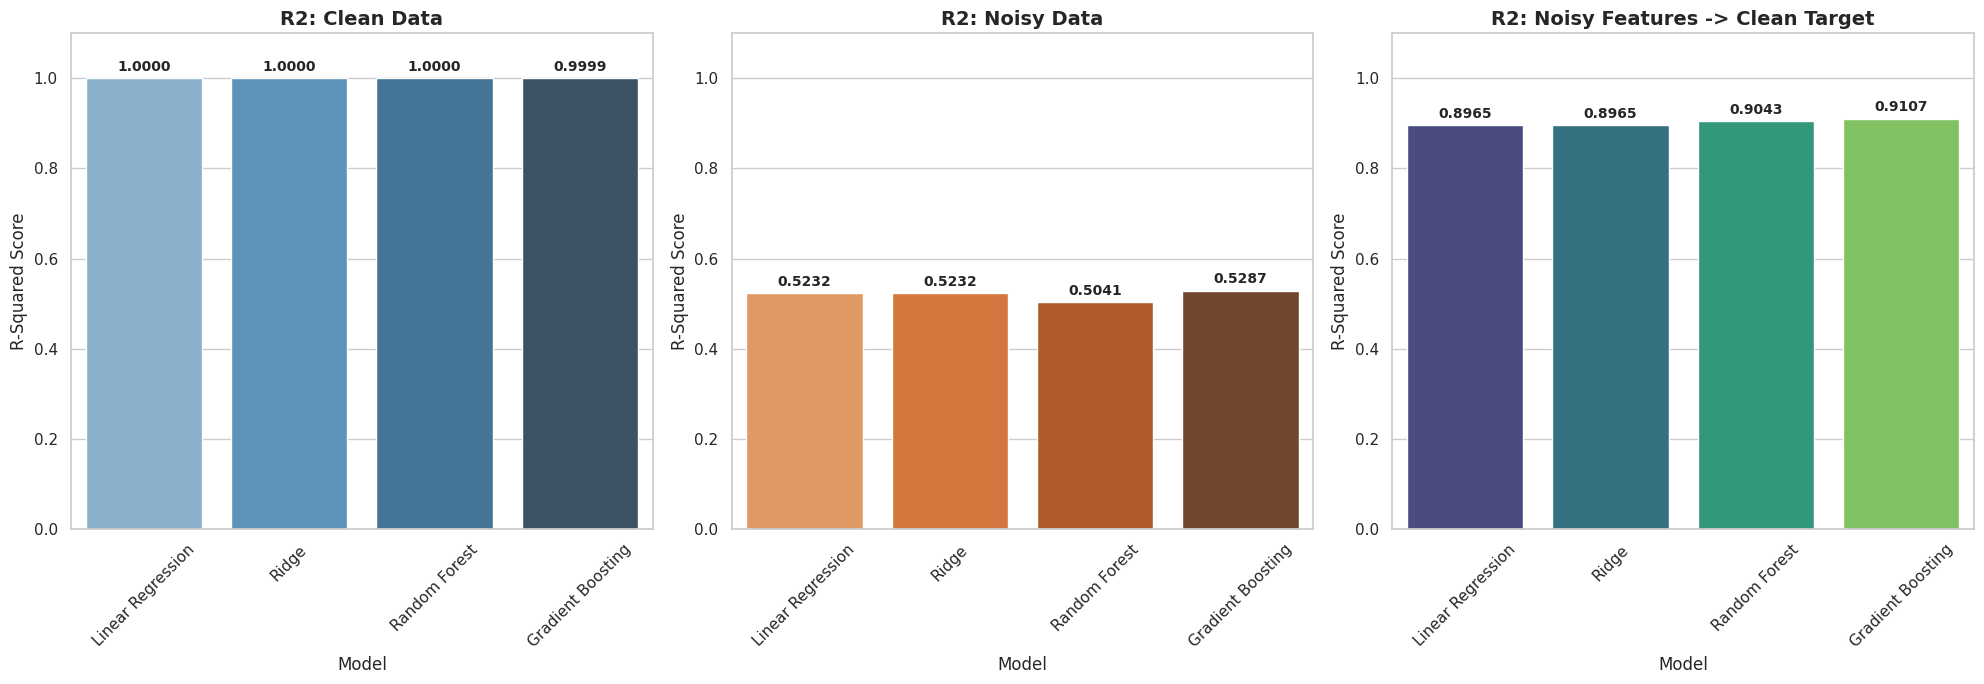

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter results for all three scenarios
clean_results = res_df[res_df['Scenario'] == 'Clean Data']
noisy_results = res_df[res_df['Scenario'] == 'Noisy Data']
recon_results = res_df[res_df['Scenario'] == 'Noisy Features to Clean Target']

fig, ax = plt.subplots(1, 3, figsize=(20, 7), sharey=False)

# Plot Clean Data R2 Scores
sns.barplot(data=clean_results, x='Model', y='R2', hue='Model', palette='Blues_d', ax=ax[0], legend=False)
ax[0].set_title('R2: Clean Data', fontsize=14, fontweight='bold')
ax[0].set_ylim(0, 1.1)
ax[0].set_ylabel('R-Squared Score')

# Plot Noisy Data R2 Scores
sns.barplot(data=noisy_results, x='Model', y='R2', hue='Model', palette='Oranges_d', ax=ax[1], legend=False)
ax[1].set_title('R2: Noisy Data', fontsize=14, fontweight='bold')
ax[1].set_ylim(0, 1.1)
ax[1].set_ylabel('R-Squared Score')

# Plot Noisy Features to Clean Target R2 Scores
sns.barplot(data=recon_results, x='Model', y='R2', hue='Model', palette='viridis', ax=ax[2], legend=False)
ax[2].set_title('R2: Noisy Features -> Clean Target', fontsize=14, fontweight='bold')
ax[2].set_ylim(0, 1.1)
ax[2].set_ylabel('R-Squared Score')

# Add text labels on top of bars for all axes
for a in ax:
    a.tick_params(axis='x', rotation=45)
    for container in a.containers:
        a.bar_label(container, fmt='%.4f', padding=3, fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 7. Feature Impact Analysis

To understand which physical parameters drive the heat load, we analyze the **Feature Importance** from a Random Forest Regressor for each of our three modeling scenarios.

/tmp/ipykernel_4771/1298441431.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette=palette, ax=ax)
/tmp/ipykernel_4771/1298441431.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette=palette, ax=ax)
/tmp/ipykernel_4771/1298441431.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='Importance', y='Feature', palette=palette, ax=ax)


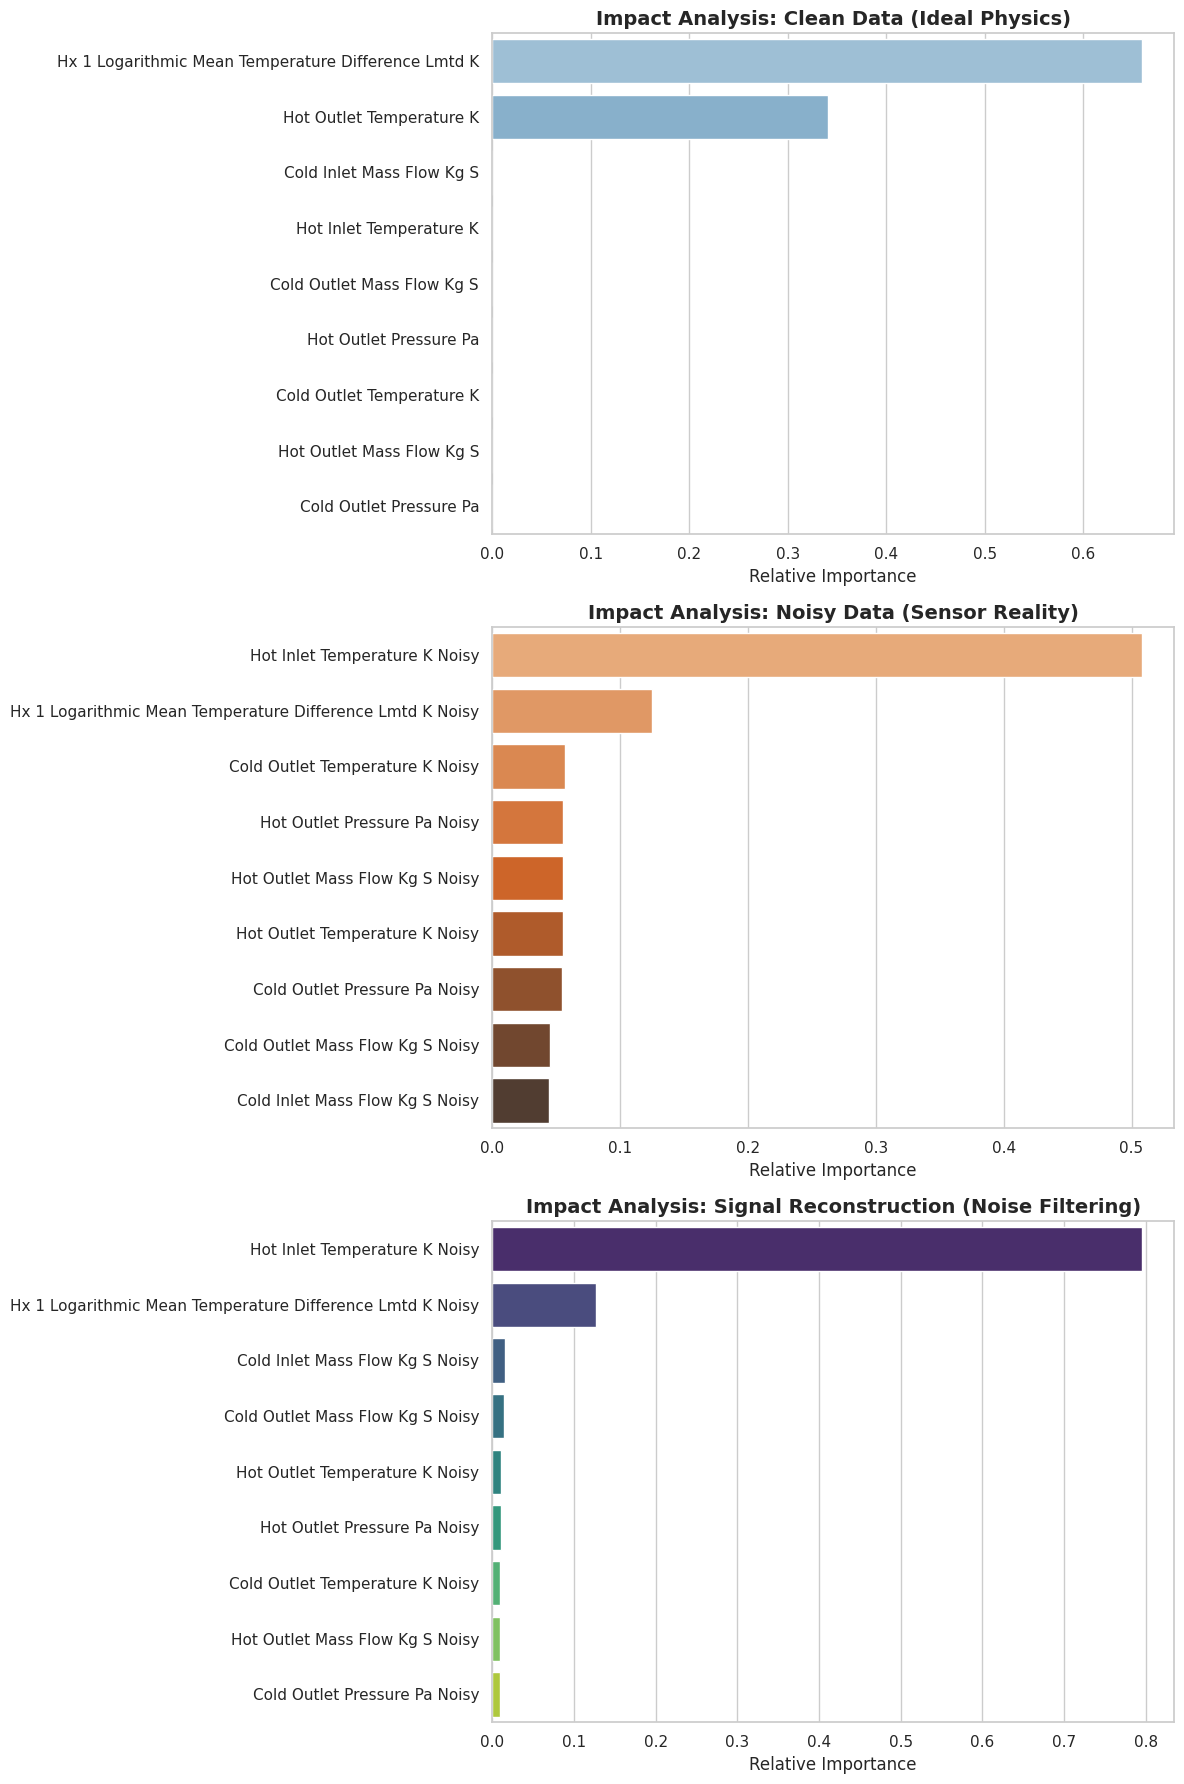

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor

def plot_feature_importance(X, y, title, palette, ax):
    # Train a Random Forest to extract importance scores
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X, y)

    # Create a DataFrame for plotting
    importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Cleanup feature names for display
    importance_df['Feature'] = importance_df['Feature'].str.replace('_', ' ').str.title()

    sns.barplot(data=importance_df, x='Importance', y='Feature', palette=palette, ax=ax)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Relative Importance')
    ax.set_ylabel('')

# Prepare the figure
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# Scenario 1: Clean Data
plot_feature_importance(
    df_clean_filtered[clean_features],
    df_clean_filtered[clean_target],
    'Impact Analysis: Clean Data (Ideal Physics)',
    'Blues_d', axes[0]
)

# Scenario 2: Noisy Data
plot_feature_importance(
    df_noisy_filtered[noisy_features],
    df_noisy_filtered[noisy_target],
    'Impact Analysis: Noisy Data (Sensor Reality)',
    'Oranges_d', axes[1]
)

# Scenario 3: Noisy Features to Clean Target
plot_feature_importance(
    df_noisy_filtered[noisy_features],
    df_noisy_filtered[clean_target],
    'Impact Analysis: Signal Reconstruction (Noise Filtering)',
    'viridis', axes[2]
)

plt.tight_layout()
plt.show()

### Key Takeaways & Engineering Insights

1. **Perfect Clean Modeling**: On uncorrupted clean data, Linear Regression yields a flawless $R^2$ score of $1.0000$. This indicates that the dataset is formed by clear deterministic physical equations, allowing a linear configuration to reverse-engineer the heat equation perfectly.
2. **The $R^2$ Noise Boundary**: When both the features and targets contain noise, performance drops across all models to an $R^2 \sim 0.53$. This drop does not mean the models are weak; rather, it reflects **irreducible error**. Because random noise is independent and non-deterministic, no model can predict the randomized variance component of `hx_1_heat_load_kw_noisy` perfectly.
3. **Noise Filtering Capability**: The most compelling result is seen in the final scenario (**Noisy Features $\rightarrow$ Clean Target**). When asked to predict the true physical heat load using corrupted sensor inputs, **Gradient Boosting** achieves an $R^2$ score of **$0.9107$** and lowers the RMSE to just **$5.77\text{ kW}$**. This demonstrates that tree-based ensemble models are highly capable of learning the underlying thermodynamics through the noise, serving effectively as soft-computing signal filters.